In [1]:
import numpy as np
from matplotlib import pyplot as plt

from loki.libloki.configs import PulsarSearchConfig
from loki.libloki.plans import FFAPlanFourier
from loki.libloki.prune import EPMultiPassFourier
from pyloki.config import ParamLimits
from pyloki.detection import thresholding
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


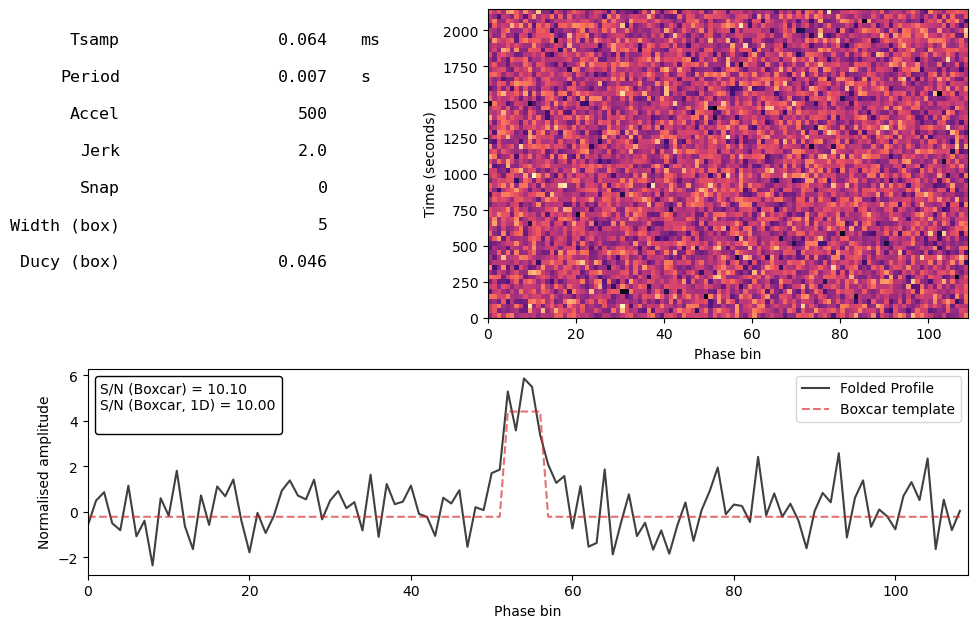

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 500
jerk = 2.0
nsamps = 2**25
mod_kwargs = {"acc": accel, "jerk": jerk}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=10.0,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_upper([jerk, accel, cfg.freq], (-2.0 * jerk, jerk * 2.0), cfg.tobs)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=3,
    nthreads=4,
    ducy_max=0.2,
    wtsp=1.1,
    use_fourier=True,
)
plan = FFAPlanFourier(search_cfg)
branching_pattern = plan.get_branching_pattern()
branching_pattern

Param limits: [[-4.00000000e+00  4.00000000e+00]
 [-3.79496730e+03  4.79496730e+03]
 [ 1.41502532e+02  1.44211753e+02]]


array([8.        , 3.        , 2.        , 3.        , 1.        ,
       3.        , 2.        , 3.        , 2.01375516, 1.4897541 ,
       1.        , 1.        , 1.        , 9.        , 2.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 2.01375516, 1.4897541 ,
       2.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 3.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 3.        , 2.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

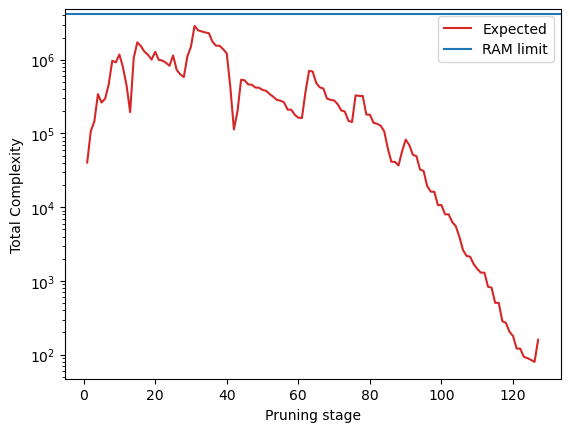

In [4]:
thresholds = np.array([2.2, 2.2, 2.5, 2.5, 2.6, 3.1, 3. , 3.1, 3.4, 3.2, 3.4, 3.6, 3.9,
       4. , 3.9, 3.8, 3.8, 3.7, 3.7, 4.2, 4.2, 3.9, 3.9, 3.9, 4.4, 4.5,
       4.4, 4.3, 4.2, 4.2, 4.1, 4.2, 4.1, 4. , 3.9, 4.2, 4.2, 3.8, 4.1,
       4.2, 4.7, 5.1, 5.2, 5.1, 4.9, 5. , 4.8, 4.9, 4.7, 4.8, 4.7, 4.8,
       4.8, 4.8, 4.7, 4.7, 4.9, 4.6, 4.9, 4.9, 4.7, 5. , 4.9, 4.8, 5.1,
       5.1, 5. , 5.2, 5.1, 5. , 5.1, 5.2, 5.1, 5.3, 5.2, 5.3, 5.3, 5. ,
       5.5, 5.3, 5.5, 5.4, 5.4, 5.5, 5.7, 5.8, 5.6, 5.7, 5.8, 5.7, 5.8,
       5.9, 5.8, 6. , 5.9, 6.1, 6.1, 5.9, 6.2, 5.9, 6.2, 5.8, 6.2, 6.2,
       6.3, 6.4, 6.4, 6.3, 6.4, 6.4, 6.4, 6. , 6.5, 6.4, 6.6, 6.3, 6.7,
       6.6, 6.7, 6.7, 6.8, 6.4, 6.8, 6.7, 6.7, 6.7, 6.3])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=9.0,
    ducy_max=0.2,
    wtsp=1.5,
)
x = np.arange(1, len(branching_pattern) + 1)
nparam_vol = plan.ncoords[-1]
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**22, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [5]:
ep_manager = EPMultiPassFourier(
    search_cfg,
    thresholds,
    n_runs=16,
    max_sugg=2**22,
    batch_size=1024,
    poly_basis="taylor",
    show_progress=False,
)
ep_manager.execute(
    tim_data.ts_e,
    tim_data.ts_v,
    outdir="pruning_results/jerk_test/",
    file_prefix="test_jerk",
)

[2026-04-09 16:14:37.865] [info] EPMultiPass: Initializing with FFA
[2026-04-09 16:14:37.915] [info] P-FFA [8192, 1, 1, 22, 2, 33] -> [128, 1, 4, 1454, 2, 33]
[2026-04-09 16:14:37.915] [info] FFA Memory Usage: 0.73 GB + 0.00 GB (coords)
[2026-04-09 16:14:40.176] [info] Starting Pruning for 16 runs, with 4 threads
[2026-04-09 16:14:40.179] [info] Pruning run 016: Memory Usage: 2.41 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:14:40.179] [info] Pruning run 008: Memory Usage: 2.41 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:14:40.179] [info] Pruning run 000: Memory Usage: 2.41 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:14:40.179] [info] Pruning run 025: Memory Usage: 2.41 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:14:40.179] [info] Pruning run 008: initialized
[2026-04-09 16:14:40.179] [info] Pruning run 016: initialized
[2026-04-09 16:14:40.179] [info] Pruning run 025: initialized
[2026-04-09 16:14:40.179] [info] Pruning run 000: initialized
[2026-04-09 16:15:08.218] [info] 

In [6]:
result_file = "pruning_results/jerk_test/test_jerk_pruning_nstages_128_results.h5"
pgram = ScatteredPeriodogram.load(result_file)
print(
    f"True params, j: {cfg.mod_kwargs['jerk']:.3f}, a: {cfg.mod_kwargs['acc']:.3f}, f: {cfg.freq:.10f}"
)
print(pgram.get_summary_cands(10, run_id=None))

True params, j: 2.000, a: 500.000, f: 142.8571428571
Top candidates:
dparams: djerk: 0.001205770418, daccel: 0.2087166993, dfreq: 1.455191523e-05
Run: 000_01, S/N: 8.21, jerk: 1.6945, accel: 4324.71, freq: 140.868510
Run: 000_01, S/N: 8.08, jerk: 1.6945, accel: 4324.71, freq: 140.868496
Run: 016_03, S/N: 8.06, jerk: 3.1851, accel: 1586.49, freq: 143.669321
Run: 025_04, S/N: 8.05, jerk: -0.2053, accel: 3801.35, freq: 140.719499
Run: 025_04, S/N: 8.01, jerk: -0.2053, accel: 3801.35, freq: 140.719513
Run: 093_12, S/N: 7.99, jerk: 1.3796, accel: -57.07, freq: 142.172164
Run: 016_03, S/N: 7.97, jerk: 3.1851, accel: 1586.49, freq: 143.669335
Run: 110_14, S/N: 7.96, jerk: -2.6649, accel: 4604.90, freq: 143.102917
Run: 067_09, S/N: 7.96, jerk: -0.7661, accel: -2357.61, freq: 142.278875
Run: 093_12, S/N: 7.95, jerk: 2.3922, accel: -861.12, freq: 142.870267


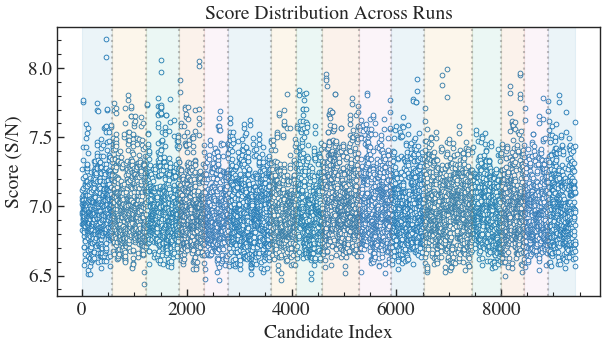

In [7]:
pgram.plot_scores(kind="scatter", run_id=None)
plt.show()

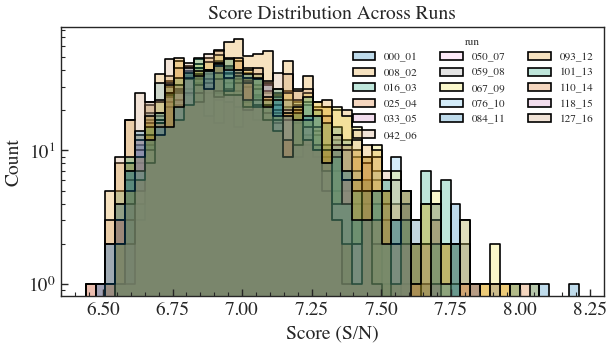

In [8]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

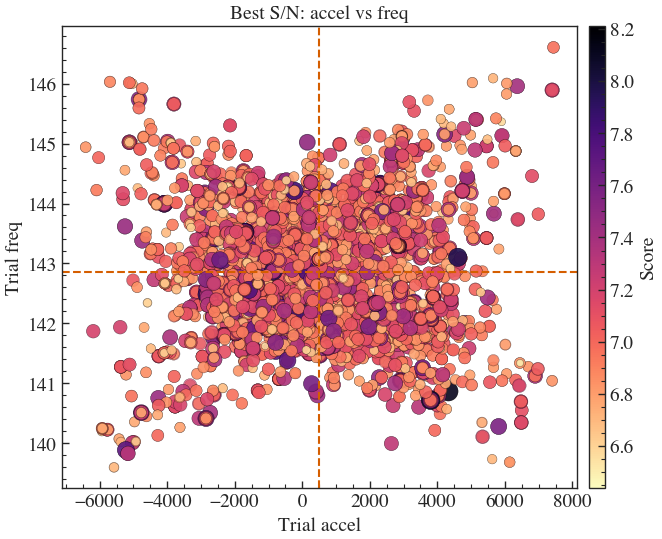

In [11]:
pgram.plot_correlation(
    "accel",
    "freq",
    true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq},
    run_id=None,
)
plt.show()

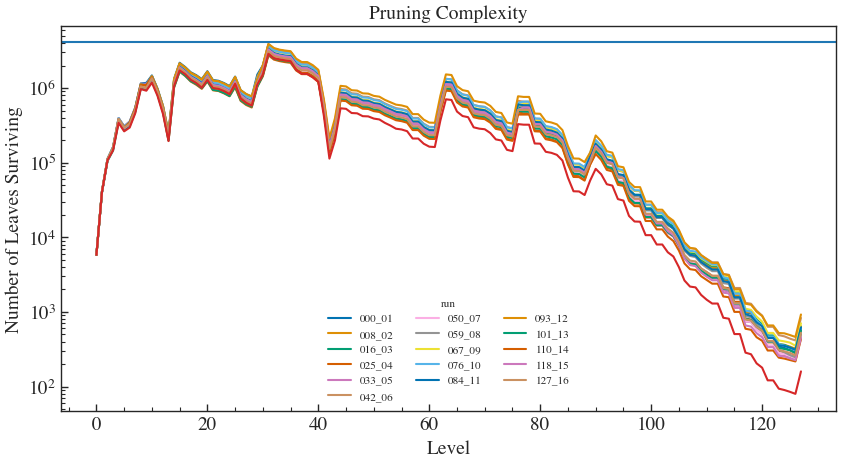

In [12]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(
    x,
    np.concatenate(([1], thresh_state.get_info("complexity"))) * nparam_vol,
    label="Expected",
    c="tab:red",
)
ax_list[0].axhline(2**22, label="RAM limit", c="tab:blue")
plt.show()